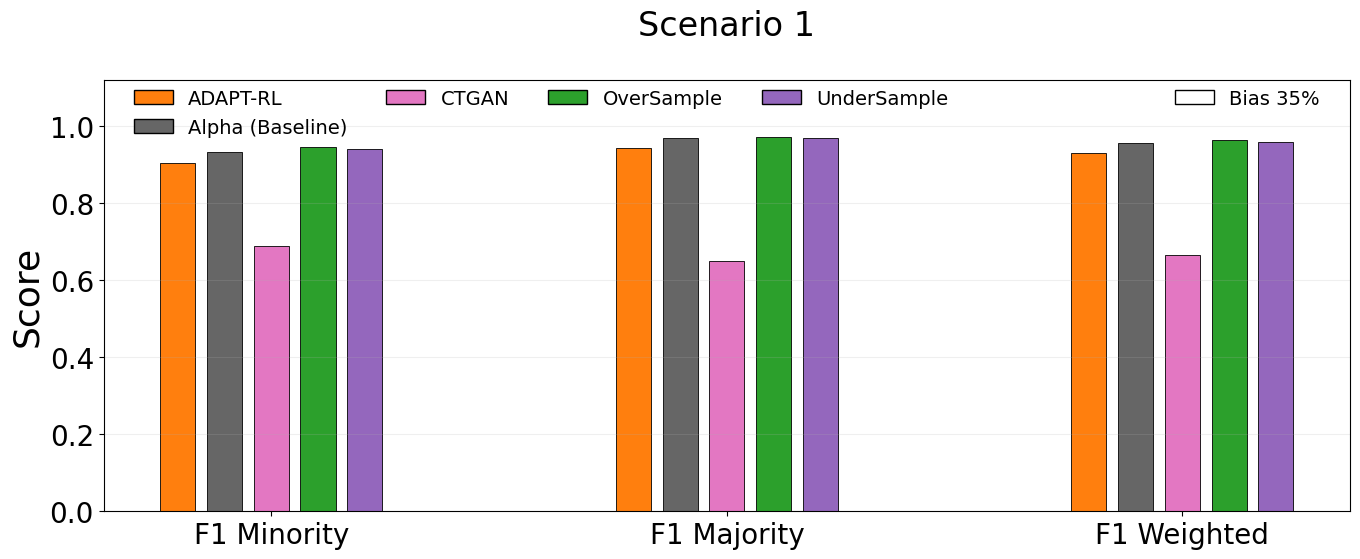


Raw values — Scenario 1
Experiment  Bias 35%                                               
Method      ADAPT-RL Alpha (Baseline)  CTGAN OverSample UnderSample
Metric                                                             
F1 Majority   0.9423           0.9666 0.6501     0.9705      0.9671
F1 Minority   0.9018           0.9323 0.6879     0.9442      0.9391
F1 Weighted   0.9281           0.9546 0.6633     0.9613      0.9573


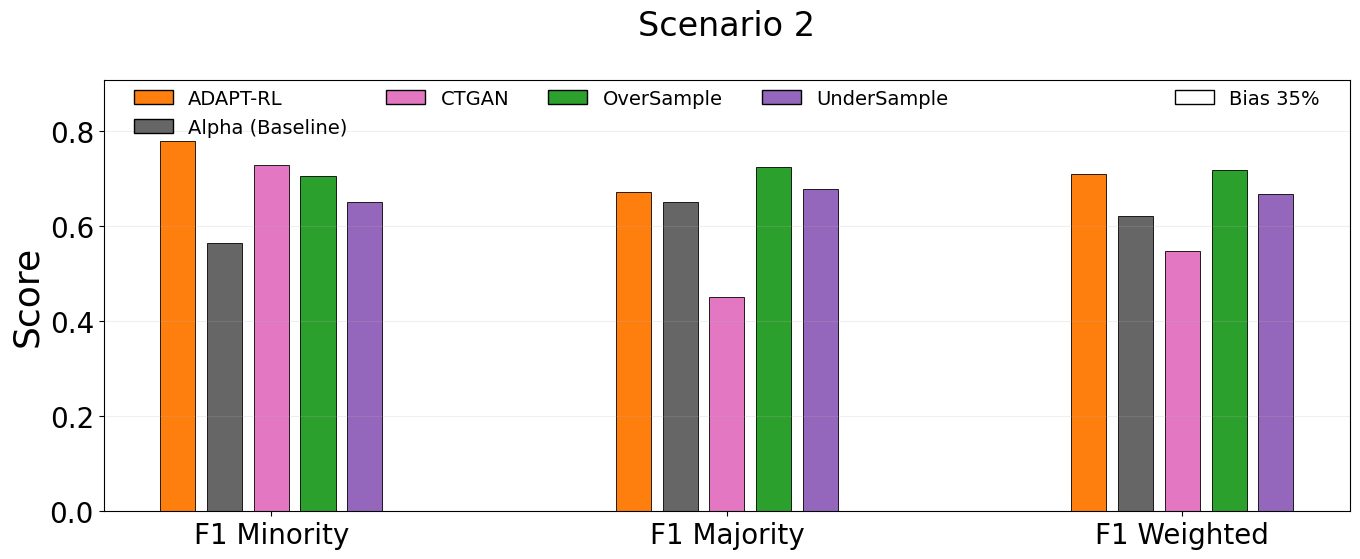


Raw values — Scenario 2
Experiment  Bias 35%                                               
Method      ADAPT-RL Alpha (Baseline)  CTGAN OverSample UnderSample
Metric                                                             
F1 Majority   0.6720           0.6505 0.4512     0.7240      0.6766
F1 Minority   0.7782           0.5635 0.7272     0.7043      0.6498
F1 Weighted   0.7092           0.6201 0.5478     0.7171      0.6672


In [9]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-

"""
One cell that plots Layout B twice (Scenario 1, then Scenario 2) and
prints the raw metric values (per Metric × Experiment × Method) under each plot.
"""

import os
import re
from typing import Dict, List, Tuple, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams

# -------------------------
# Display styling
# -------------------------
rcParams['font.size'] = 20
rcParams['axes.labelsize'] = 26
rcParams['axes.titlesize'] = 24
rcParams['xtick.labelsize'] = 20
rcParams['ytick.labelsize'] = 20
rcParams['legend.fontsize'] = 14
rcParams['axes.titlepad'] = 0

# =========================
# Config you may customize
# =========================
TEST_METRICS: List[Tuple[str, str]] = [
    ("f1_minority", "F1 Minority"),
    ("f1_majority", "F1 Majority"),
    ("f1_weighted", "F1 Weighted"),
]

METHOD_LABELS = {
    "alpha":        "Alpha (Baseline)",
    "beta":         "ADAPT-RL",
    "oversample":   "OverSample",
    "undersample":  "UnderSample",
    "alphaplusreal":"Alpha_Plusreal",
    "alpharaworig": "Alpha_Raworig",
    "ctgan":        "CTGAN",
    "proposed":     "Proposed (RL)",
    "rl":           "Proposed (RL)",
}
METHOD_COLORS = {
    "alpha":        "#666666",
    "beta":         "#ff7f0e",
    "oversample":   "#2ca02c",
    "undersample":  "#9467bd",
    "alphaplusreal":"#1f77b4",
    "alpharaworig": "#8c564b",
    "ctgan":        "#e377c2",
    "proposed":     "#d62728",
    "rl":           "#d62728",
}

EXPERIMENT_HATCHES = ["", "//", "\\\\", "xx", ".."]
EXPERIMENT_ALPHAS  = [1.00, 0.80, 0.65, 0.55, 0.50]
HEADROOM = 1.10

# =========================
# Small helpers
# =========================
def _norm(s: str) -> str:
    return re.sub(r"[^a-z0-9]", "", str(s).lower())

def read_final_rows(exp_root: str) -> List[pd.Series]:
    rows = []
    if not os.path.isdir(exp_root):
        print(f"[warn] not a dir: {exp_root}")
        return rows
    for d in sorted(os.listdir(exp_root)):
        sd = os.path.join(exp_root, d)
        if not (os.path.isdir(sd) and d.startswith("seed_")):
            continue
        p = os.path.join(sd, "final_test_metrics.csv")
        if os.path.isfile(p):
            try:
                df = pd.read_csv(p)
                if not df.empty:
                    rows.append(df.iloc[-1])
            except Exception as e:
                print(f"[warn] reading {p}: {e}")
    if not rows:
        roll = os.path.join(exp_root, "final_test_metrics.csv")
        if os.path.isfile(roll):
            try:
                df = pd.read_csv(roll)
                for _, r in df.iterrows():
                    rows.append(r)
            except Exception as e:
                print(f"[warn] reading rollup {roll}: {e}")
    return rows

def detect_prefixes(df: pd.DataFrame) -> List[str]:
    prefixes = set()
    for c in df.columns:
        if "_" not in c:
            continue
        p, suf = c.split("_", 1)
        for key, _ in TEST_METRICS:
            if key == "f1_weighted":
                continue
            if suf == key or suf.endswith(key):
                prefixes.add(p)
                break
    return sorted(prefixes)

def mean_of(df: pd.DataFrame, col: str) -> float:
    return float(pd.to_numeric(df.get(col), errors="coerce").mean(skipna=True)) if col in df.columns else np.nan

def pretty_method(prefix: str) -> str:
    return METHOD_LABELS.get(prefix, prefix.title())

def method_color(prefix: str) -> Optional[str]:
    return METHOD_COLORS.get(prefix, None)

def inject_manual_method(exp_dfs: Dict[str, pd.DataFrame], method_prefix: str, manual_values: Dict[str, Dict[str, float]]) -> None:
    for exp_label, metric_map in manual_values.items():
        if exp_label not in exp_dfs:
            exp_dfs[exp_label] = pd.DataFrame([{}])
        df = exp_dfs[exp_label]
        for key, val in metric_map.items():
            if np.isfinite(val):
                df[f"{method_prefix}_{key}"] = float(val)

def CTGAN(values: Dict[str, Dict[str, float]]) -> Dict[str, Dict[str, float]]:
    return values

# ---- F1 weighted helpers ----
_BIAS_LABEL_RE = re.compile(r"bias\s*(\d+(?:\.\d+)?)\s*%", re.IGNORECASE)
def infer_weights_from_label(exp_label: str) -> Tuple[float, float]:
    m = _BIAS_LABEL_RE.search(exp_label or "")
    if not m:
        return 0.5, 0.5
    pct = max(0.0, min(1.0, float(m.group(1)) / 100.0))
    return pct, 1.0 - pct

def build_weights_map(exp_labels: List[str]) -> Dict[str, Tuple[float, float]]:
    return {lbl: infer_weights_from_label(lbl) for lbl in exp_labels}

def get_metric_value(df: pd.DataFrame, prefix: str, metric_key: str, exp_label: str, weights_map: Dict[str, Tuple[float, float]]) -> float:
    if metric_key == "f1_weighted":
        w_min, w_maj = weights_map.get(exp_label, (0.5, 0.5))
        f1_min = mean_of(df, f"{prefix}_f1_minority")
        f1_maj = mean_of(df, f"{prefix}_f1_majority")
        if not np.isfinite(f1_min) or not np.isfinite(f1_maj):
            return np.nan
        return w_min * f1_min + w_maj * f1_maj
    if metric_key == "brier":
        v = mean_of(df, f"{prefix}_brier")
        return 1.0 - v if np.isfinite(v) else np.nan
    return mean_of(df, f"{prefix}_{metric_key}")

# =========================
# Layout B (now also returns a DataFrame of raw values)
# =========================
def plot_layout_B(
    experiments: Dict[str, str],
    keep_methods: List[str],
    title_suffix: str = "layout B",
    ctgan_manual: Optional[Dict[str, Dict[str, float]]] = None,
) -> pd.DataFrame:
    # 1) load data
    exp_keys = list(experiments.keys())
    exp_rows = {k: read_final_rows(experiments[k]) for k in exp_keys}

    # Build DataFrames; allow CTGAN-only via manual injection
    exp_dfs: Dict[str, pd.DataFrame] = {}
    for k in exp_keys:
        rows = exp_rows.get(k, [])
        if rows:
            exp_dfs[k] = pd.DataFrame(rows)
        elif ctgan_manual and k in ctgan_manual:
            exp_dfs[k] = pd.DataFrame([{}])

    # Inject manual CTGAN values if provided
    if ctgan_manual:
        inject_manual_method(exp_dfs, "ctgan", ctgan_manual)

    if not exp_dfs:
        raise SystemExit("No experiments produced final rows or manual CTGAN values.")

    # common prefixes
    common = None
    for _, df in exp_dfs.items():
        pref = set(detect_prefixes(df))
        common = pref if common is None else (common & pref)
    if not common:
        raise SystemExit("No common method prefixes across experiments.")
    if keep_methods:
        want = {_norm(x) for x in keep_methods}
        common = {p for p in common if _norm(p) in want or _norm(pretty_method(p)) in want}
        if not common:
            raise SystemExit("None of the requested methods exist in data.")

    methods = sorted(common, key=lambda p: pretty_method(p))
    weights_map = build_weights_map(exp_keys)

    # --- collect values while plotting ---
    records = []  # rows: dict(Metric, Experiment, Method, Value)

    # 2) layout constants
    M = len(TEST_METRICS)
    N_methods = len(methods)
    N_exps = len(exp_dfs)
    def _layout_no_overlap(n_slots: int, bar_width: float, inner_gap: float):
        total_width = n_slots * bar_width + (n_slots - 1) * inner_gap
        left_edge = - total_width / 2.0
        centers, pos = [], left_edge + bar_width/2.0
        for _ in range(n_slots):
            centers.append(pos); pos += bar_width + inner_gap
        return np.asarray(centers), total_width

    METH_BAR_WIDTH = 0.18
    METH_INNER_GAP = 0.06
    meth_offsets, meth_block_width = _layout_no_overlap(N_methods, METH_BAR_WIDTH, METH_INNER_GAP)
    EXP_INNER_GAP = 0.40
    exp_offsets, exp_block_width = _layout_no_overlap(N_exps, meth_block_width, EXP_INNER_GAP)
    METRIC_GAP = 1.20
    x_metric_centers = np.arange(M) * (exp_block_width + METRIC_GAP)

    # 3) draw
    fig, ax = plt.subplots(figsize=(14, 6))
    method_handles, exp_handles = [], []
    max_val = 0.0

    for mi, (metric_key, metric_label) in enumerate(TEST_METRICS):
        cx = x_metric_centers[mi]

        for ei, ek in enumerate(exp_keys):
            if ek not in exp_dfs:
                continue
            ex = cx + exp_offsets[ei]
            hatch = EXPERIMENT_HATCHES[ei % len(EXPERIMENT_HATCHES)]
            alpha = EXPERIMENT_ALPHAS[ei % len(EXPERIMENT_ALPHAS)]
            df = exp_dfs[ek]

            for mj, prefix in enumerate(methods):
                bx = ex + meth_offsets[mj]
                val = get_metric_value(df, prefix, metric_key, ek, weights_map)
                color = method_color(prefix)
                ax.bar(bx, val, METH_BAR_WIDTH, color=color, edgecolor="black", linewidth=0.6,
                       hatch=hatch, alpha=alpha)
                if np.isfinite(val):
                    max_val = max(max_val, val)

                # collect raw
                records.append({
                    "Metric": metric_label,
                    "Experiment": ek,
                    "Method": pretty_method(prefix),
                    "Value": float(val) if np.isfinite(val) else np.nan,
                })

                # legends once
                if mi == 0 and ei == 0:
                    method_handles.append((plt.Rectangle((0, 0), 1, 1, fc=color, ec="black"),
                                           pretty_method(prefix)))
                if mi == 0 and mj == 0:
                    exp_handles.append((plt.Rectangle((0, 0), 1, 1, fc="white", ec="black",
                                                      hatch=hatch, alpha=alpha), ek))

    ax.set_xticks(x_metric_centers, [lbl for (_, lbl) in TEST_METRICS])
    if np.isfinite(max_val) and max_val > 0:
        ax.set_ylim(top=min(2.5, HEADROOM * max_val + 0.05))
    ax.set_ylabel("Score")
    ax.grid(axis="y", alpha=0.2)
    ax.set_title(f"{title_suffix}\n")

    if method_handles:
        h, l = zip(*method_handles)
        leg1 = ax.legend(h, l, loc="upper left", bbox_to_anchor=(0.01, 1.02),
                         ncol=min(4, len(l)), frameon=False, title="")
        ax.add_artist(leg1)
    if exp_handles:
        h, l = zip(*exp_handles)
        ax.legend(h, l, loc="upper right", bbox_to_anchor=(0.99, 1.02),
                  ncol=min(4, len(l)), frameon=False, title="")

    plt.tight_layout()
    plt.show()

    # ---- print raw values below the plot ----
    df_records = pd.DataFrame.from_records(records)
    pivot = (df_records
             .pivot(index="Metric", columns=["Experiment", "Method"], values="Value")
             .sort_index(axis=1))
    with pd.option_context("display.float_format", "{:.4f}".format):
        print(f"\nRaw values — {title_suffix}")
        print(pivot)

    return df_records  # also return if you want to save/export later

# =========================
# Run both scenarios (Layout B only)
# =========================
if __name__ == "__main__":
    # -------- Scenario 1 --------
    experiments_1 = {
        #"Bias 5%":  "training_runs_oct19//EP2000_PCA4_REWlocal_gauss_minID13_majID4_TRJ2000_REAL3000_BIAS0.25_DATE20251018_G202510171350_4e009933",
        "Bias 35%": "training_runs_oct19/EP2000_PCA4_REWlocal_gauss_minID13_majID4_TRJ2000_REAL3000_BIAS0.25_DATE20251018_G202510171350_4e009933",
    }
    ctgan_manual_1 = CTGAN({
        #"Bias 5%":  {"f1_minority": 0.6594, "f1_majority": 0.6555, "f1_weighted": 0.6577},
        "Bias 35%": {"f1_minority": 0.6879, "f1_majority": 0.6501, "f1_weighted": 0.6648},
    })
    keep_methods = ["alpha", "beta", "oversample", "undersample", "ctgan"]
    _df1 = plot_layout_B(experiments_1, keep_methods, title_suffix="Scenario 1", ctgan_manual=ctgan_manual_1)

    # -------- Scenario 2 --------
    experiments_2 = {
        #"Bias 5%":  "training_runs/EP2000_PCA4_REWlocal_gauss_minID12_majID13_TRJ2000_REAL3000_BIAS0.05_DATE20251020_G202510201105_6669a56d",
        "Bias 35%": "training_runs_oct19/EP2000_PCA4_REWlocal_gauss_minID12_majID13_TRJ2000_REAL3000_BIAS0.35_DATE20251017_G202510151440_d376570a",
    }
    ctgan_manual_2 = CTGAN({
        #"Bias 5%":  {"f1_minority": 0.7207, "f1_majority": 0.4284, "f1_weighted": 0.5809},
        "Bias 35%": {"f1_minority": 0.7272, "f1_majority": 0.4512, "f1_weighted": 0.5945},
    })
    _df2 = plot_layout_B(experiments_2, keep_methods, title_suffix="Scenario 2", ctgan_manual=ctgan_manual_2)


In [ ]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-

"""
PAMAP2 separability plot in PCA(2D), no splits.

What it does
------------
- Loads all PAMAP2 .dat files (Protocol/Optional).
- Keeps ONLY two activity IDs that you specify.
- Per-subject linear interpolation for NaNs (no cross-subject leakage).
- Builds compact features per 5s window (50% overlap):
    heart_rate + norms of (acc16g, gyro) at hand/chest/ankle
    and computes (std, rms) for each channel within the window.
- Fits StandardScaler + PCA(n_components=2) on the ENTIRE resulting table.
- Plots ALL windows from the two classes in 2D, plus centroids and their distance.
- Optionally draws a linear boundary (centroid bisector or LDA).
- Saves a PNG.

Edit the CONFIG section below to pick your two activity IDs and paths.
"""

import os
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from matplotlib import rcParams

rcParams['font.size'] = 1          # 3× bigger default text
rcParams['axes.labelsize'] = 16     # x/y label size
rcParams['axes.titlesize'] = 24     # title size
rcParams['xtick.labelsize'] = 14    # x tick labels
rcParams['ytick.labelsize'] = 14    # y tick labels
rcParams['legend.fontsize'] = 14    # legend text


# =========================
# CONFIG — EDIT THESE
# =========================
DATA_ROOT = "datasets/PAMAP2_Dataset"   # root folder containing Protocol/Optional
MAJORITY_ID = 13    # e.g., walking
MINORITY_ID = 12     # e.g., rope jumping
INCLUDE_THIRD = False     # keep exactly two classes; leave False
THIRD_ID = 13             # ignored when INCLUDE_THIRD=False

WIN_SECONDS = 5.0         # window size
STEP_SECONDS = 2.5        # 50% overlap
FS = 100                  # PAMAP2 sampling (Hz)
DROP_MAGNETOMETERS = True # keep features compact
USE_VECTOR_NORMS = True   # collapse x/y/z to a single norm per sensor
FEATURE_STATS = ("std", "rms")  # per-window stats to compute
SEED = 42                 # only used for file ordering reproducibility

# Linear boundary mode: "bisector" (perpendicular bisector of centroids) or "lda" (Linear Discriminant Analysis)
BOUNDARY_MODE = "bisector"

FIG_SIZE = (8.0, 6.5)
ALPHA = 0.28              # point transparency
POINT_SIZE = 8            # scatter marker size
SAVE_PNG = True
PNG_NAME = f"pamap2_pca2_separability_{MAJORITY_ID}_vs_{MINORITY_ID}.png"
# =========================


# ---------- helpers ----------
def _colnames():
    cols = ["timestamp", "activity_id", "heart_rate"]
    sub = [
        "temp","acc16g_x","acc16g_y","acc16g_z","acc6g_x","acc6g_y","acc6g_z",
        "gyro_x","gyro_y","gyro_z","mag_x","mag_y","mag_z",
        "orient_w","orient_x","orient_y","orient_z"
    ]
    for p in ["hand", "chest", "ankle"]:
        cols += [f"{p}_{s}" for s in sub]
    return cols  # 54 total

def _parse_subject_id(path: Path) -> str:
    m = re.search(r"subject(\d+)", path.stem.lower())
    return m.group(1) if m else "unknown"

def _load_all_dat_files(data_root: str) -> pd.DataFrame:
    root = Path(data_root)
    files = []
    for sub in ["Protocol", "Optional", "protocol", "optional"]:
        d = root / sub
        if d.exists():
            files += list(d.glob("subject*.dat"))
    if not files:
        raise FileNotFoundError(f"No .dat files found under {root} (looked in Protocol/Optional).")

    files = sorted(files, key=lambda p: (p.parent.name.lower(), p.name.lower()))
    rows = []
    for f in files:
        df = pd.read_csv(
            f, sep=r"\s+", header=None, names=_colnames(),
            engine="python", na_values=["NaN","nan"]
        )
        df["subject_id"] = _parse_subject_id(f)
        rows.append(df)
    out = pd.concat(rows, ignore_index=True)
    return out

def _interpolate_per_subject(df: pd.DataFrame) -> pd.DataFrame:
    # interpolate numerics *within each subject* to avoid cross-subject leakage
    num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    # don't interpolate the label column
    num_cols = [c for c in num_cols if c != "activity_id"]
    df = df.sort_values(["subject_id", "timestamp"])
    df = df.groupby("subject_id", group_keys=False).apply(
        lambda g: g.assign(**{c: g[c].interpolate(limit_direction="both") for c in num_cols})
    )
    return df.reset_index(drop=True)

def _build_base_channels(df: pd.DataFrame, drop_magnetometers=True, use_vector_norms=True):
    imu_pos = ["hand", "chest", "ankle"]
    ACC16 = ["acc16g_x","acc16g_y","acc16g_z"]
    GYR   = ["gyro_x","gyro_y","gyro_z"]
    MAG   = ["mag_x","mag_y","mag_z"]

    keep_triplets = [("acc", ACC16), ("gyr", GYR)]
    if not drop_magnetometers:
        keep_triplets.append(("mag", MAG))

    base_cols = ["heart_rate"]
    if use_vector_norms:
        for p in imu_pos:
            for name, axes in keep_triplets:
                cols = [f"{p}_{a}" for a in axes]
                df[f"{p}_{name}_norm"] = np.sqrt((df[cols].values ** 2).sum(axis=1))
                base_cols.append(f"{p}_{name}_norm")
    else:
        for p in imu_pos:
            for _, axes in keep_triplets:
                for a in axes:
                    base_cols.append(f"{p}_{a}")
    return df, base_cols

def _window_features(df: pd.DataFrame, base_cols, fs=100, win_s=5.0, step_s=2.5, stats=("std","rms")):
    """Return (feature_df, labels, subjects). Labels are original activity_id mapped later."""
    WIN = int(win_s * fs)
    STEP = int(step_s * fs)

    # Sort by subject/time so windows are contiguous per subject
    df = df.sort_values(["subject_id","timestamp"]).reset_index(drop=True)

    # We'll store per-window feature rows
    feats_rows = []
    labels = []
    subjects = []

    compute_std = ("std" in stats)
    compute_rms = ("rms" in stats)
    compute_mean= ("mean" in stats)

    for sid, g in df.groupby("subject_id", sort=False):
        g = g.reset_index(drop=True)
        n = len(g)
        if n < WIN:
            continue
        # Sliding windows
        for start in range(0, n - WIN + 1, STEP):
            w = g.iloc[start:start + WIN]
            Xw = w[base_cols]

            # window label = majority label within the window
            y_win = int(np.bincount(w["activity_id"].astype(int)).argmax())

            fdict = {}
            if compute_mean:
                fdict.update(Xw.mean().add_suffix("__mean").to_dict())
            if compute_std:
                fdict.update(Xw.std(ddof=1).add_suffix("__std").to_dict())
            if compute_rms:
                fdict.update((np.sqrt((Xw**2).mean())).add_suffix("__rms").to_dict())

            fdict["subject_id"] = sid
            feats_rows.append(fdict)
            labels.append(y_win)
            subjects.append(sid)

    feat_df = pd.DataFrame(feats_rows).fillna(0.0)
    labels = np.asarray(labels, dtype=int)
    subjects = np.asarray(subjects)
    return feat_df, labels, subjects

def _plot_linear_boundary(ax, mode, X2, y_bin, m0, m1, seed=42):
    """
    Draw a linear boundary in the PCA(2D) plane.
    - 'bisector': line perpendicular to (m1 - m0) passing through their midpoint.
    - 'lda':      sklearn LDA boundary fit on (X2, y_bin).
    """
    x_min, x_max = ax.get_xlim()
    xs = np.linspace(x_min, x_max, 200)

    if mode == "lda":
        lda = LinearDiscriminantAnalysis()
        lda.fit(X2, y_bin)
        # decision: w0 + w1*x + w2*y = 0  ->  y = -(w0 + w1*x)/w2
        w = lda.coef_[0]      # [w1, w2]
        b = lda.intercept_[0] # w0
        if np.isclose(w[1], 0.0):
            # vertical-ish; draw a vertical line at x = -b/w1
            x0 = -b / (w[0] if w[0] != 0 else 1e-9)
            ax.axvline(x0, linestyle="--", linewidth=1.5, alpha=0.9, label="LDA boundary")
            return
        ys = -(b + w[0]*xs) / w[1]
        ax.plot(xs, ys, linestyle="--", linewidth=1.5, alpha=0.9, label="LDA boundary")
    else:
        # Perpendicular bisector between centroids
        n = (m1 - m0)  # normal
        if np.allclose(n, 0):
            return
        mid = 0.5*(m0 + m1)
        # direction vector perpendicular to n (rotate 90°)
        v = np.array([-n[1], n[0]])
        v = v / (np.linalg.norm(v) + 1e-12)

        # Create a long segment across current axes limits
        span = (x_max - x_min) * 1.2
        p1 = mid - span * v
        p2 = mid + span * v
        ax.plot([p1[0], p2[0]], [p1[1], p2[1]], linestyle="--", linewidth=1.5, alpha=0.9, label="Centroid bisector")

# ---------- main ----------
def main():
    # 1) Load all PAMAP2 rows
    print("[info] loading PAMAP2…")
    df = _load_all_dat_files(DATA_ROOT)

    # 2) Keep exactly the two activity IDs (optionally a third if INCLUDE_THIRD=True)
    keep_ids = [MAJORITY_ID, MINORITY_ID] if not INCLUDE_THIRD else [MAJORITY_ID, MINORITY_ID, THIRD_ID]
    df = df[df["activity_id"].isin(keep_ids)].copy()
    if df.empty:
        raise RuntimeError("No rows remain after filtering to selected activity IDs.")

    # 3) Per-subject interpolation for NaNs
    print("[info] interpolating per subject…")
    df = _interpolate_per_subject(df)

    # 4) Build base channels (heart + IMU norms); no leakage
    print("[info] constructing base channels…")
    df, base_cols = _build_base_channels(
        df,
        drop_magnetometers=DROP_MAGNETOMETERS,
        use_vector_norms=USE_VECTOR_NORMS
    )

    # 5) Window → features (std, rms)
    print("[info] windowing → features…")
    feat_df, y_raw, subj = _window_features(
        df, base_cols,
        fs=FS, win_s=WIN_SECONDS, step_s=STEP_SECONDS,
        stats=FEATURE_STATS
    )
    if feat_df.empty:
        raise RuntimeError("No windows produced; check DATA_ROOT and config.")

    # 6) Map activity IDs to binary labels (0/1) for the two classes
    if INCLUDE_THIRD:
        # If you set INCLUDE_THIRD=True, we still only PLOT the two classes of interest
        # but we keep all points in PCA fit.
        pass
    # Keep all points from the two classes for PCA fit, too.
    mask_keep = np.isin(y_raw, [MAJORITY_ID, MINORITY_ID]) if not INCLUDE_THIRD \
                else np.isin(y_raw, [MAJORITY_ID, MINORITY_ID, THIRD_ID])
    feat_df = feat_df[mask_keep].reset_index(drop=True)
    y_raw = y_raw[mask_keep]

    # map to 0/1 for plotting consistency (majority->0, minority->1)
    y_bin = np.where(y_raw == MINORITY_ID, 1, 0)

    # 7) Prepare numeric features, scale + PCA(2) on the ENTIRE dataset
    meta_cols = ["subject_id"]
    feat_cols = [c for c in feat_df.columns if c not in meta_cols]
    X = feat_df[feat_cols].values

    print("[info] fitting StandardScaler + PCA(2) on ALL windows…")
    scaler = StandardScaler()
    Xz = scaler.fit_transform(X)

    pca = PCA(n_components=2, svd_solver="full", random_state=SEED)
    X2 = pca.fit_transform(Xz)

    # 8) Quick separability metric: centroid distance
    m0 = X2[y_bin == 0].mean(axis=0)
    m1 = X2[y_bin == 1].mean(axis=0)
    centroid_dist = float(np.linalg.norm(m1 - m0))
    print(f"[info] windows: class0={np.sum(y_bin==0)}, class1={np.sum(y_bin==1)}, "
          f"centroid distance={centroid_dist:.3f}")

    # 9) Plot ALL points
    print("[info] plotting…")
    fig, ax = plt.subplots(figsize=FIG_SIZE)

    ax.scatter(X2[y_bin==0, 0], X2[y_bin==0, 1],
               s=POINT_SIZE, alpha=ALPHA, marker="o", label=f"Descending Stairs")
    ax.scatter(X2[y_bin==1, 0], X2[y_bin==1, 1],
               s=POINT_SIZE, alpha=ALPHA, marker="^", label=f"Walking")

    # centroids + connecting line
    ax.scatter([m0[0]], [m0[1]], s=150, c="black", marker="X", label="Centroid Descending Stairs")
    ax.scatter([m1[0]], [m1[1]], s=150, c="black", marker="P", label="Centroid Ascending Stairs")
    ax.plot([m0[0], m1[0]], [m0[1], m1[1]], c="black", lw=1.2, alpha=0.7)

    # draw a linear decision boundary in PCA space
    _plot_linear_boundary(ax, BOUNDARY_MODE, X2, y_bin, m0, m1, seed=SEED)

    ax.set_xlabel("Descending stairs")
    ax.set_ylabel("Ascending Stairs")
    ax.set_title(f"Scenario 2")
    ax.legend(loc="best", frameon=False)
    ax.grid(alpha=0.25)
    plt.tight_layout()

    if SAVE_PNG:
        plt.savefig(PNG_NAME, dpi=180)
        print(f"[info] saved → {PNG_NAME}")

    plt.show()


if __name__ == "__main__":
    main()


[info] loading PAMAP2…


[info] loading PAMAP2…
[info] interpolating per subject…


/tmp/ipykernel_1572/3898548986.py:111: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby("subject_id", group_keys=False).apply(


[info] constructing base channels…
[info] windowing → features…
[info] fitting StandardScaler + PCA(2) on ALL windows…
[info] windows: class0=416, class1=946, centroid distance=3.342
[info] plotting…
[info] saved → pamap2_pca2_separability_13_vs_4.png


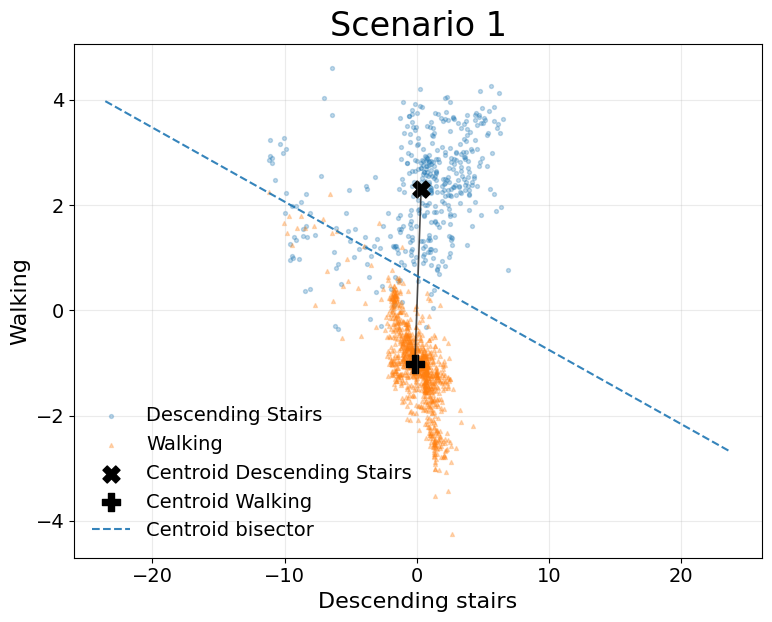

In [ ]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-

"""
PAMAP2 separability plot in PCA(2D), no splits.

What it does
------------
- Loads all PAMAP2 .dat files (Protocol/Optional).
- Keeps ONLY two activity IDs that you specify.
- Per-subject linear interpolation for NaNs (no cross-subject leakage).
- Builds compact features per 5s window (50% overlap):
    heart_rate + norms of (acc16g, gyro) at hand/chest/ankle
    and computes (std, rms) for each channel within the window.
- Fits StandardScaler + PCA(n_components=2) on the ENTIRE resulting table.
- Plots ALL windows from the two classes in 2D, plus centroids and their distance.
- Optionally draws a linear boundary (centroid bisector or LDA).
- Saves a PNG.

Edit the CONFIG section below to pick your two activity IDs and paths.
"""

import os
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
rcParams['font.size'] = 18          # 3× bigger default text
rcParams['axes.labelsize'] = 16     # x/y label size
rcParams['axes.titlesize'] = 24     # title size
rcParams['xtick.labelsize'] = 18    # x tick labels
rcParams['ytick.labelsize'] = 18    # y tick labels
rcParams['legend.fontsize'] = 18    # legend text
# =========================
# CONFIG — EDIT THESE
# =========================
DATA_ROOT = "datasets/PAMAP2_Dataset"   # root folder containing Protocol/Optional
MAJORITY_ID = 13    # e.g., walking
MINORITY_ID = 4     # e.g., rope jumping
INCLUDE_THIRD = False     # keep exactly two classes; leave False
THIRD_ID = 13             # ignored when INCLUDE_THIRD=False

WIN_SECONDS = 5.0         # window size
STEP_SECONDS = 2.5        # 50% overlap
FS = 100                  # PAMAP2 sampling (Hz)
DROP_MAGNETOMETERS = True # keep features compact
USE_VECTOR_NORMS = True   # collapse x/y/z to a single norm per sensor
FEATURE_STATS = ("std", "rms")  # per-window stats to compute
SEED = 42                 # only used for file ordering reproducibility

# Linear boundary mode: "bisector" (perpendicular bisector of centroids) or "lda" (Linear Discriminant Analysis)
BOUNDARY_MODE = "bisector"

FIG_SIZE = (8.0, 6.5)
ALPHA = 0.28              # point transparency
POINT_SIZE = 8            # scatter marker size
SAVE_PNG = True
PNG_NAME = f"pamap2_pca2_separability_{MAJORITY_ID}_vs_{MINORITY_ID}.png"
# =========================


# ---------- helpers ----------
def _colnames():
    cols = ["timestamp", "activity_id", "heart_rate"]
    sub = [
        "temp","acc16g_x","acc16g_y","acc16g_z","acc6g_x","acc6g_y","acc6g_z",
        "gyro_x","gyro_y","gyro_z","mag_x","mag_y","mag_z",
        "orient_w","orient_x","orient_y","orient_z"
    ]
    for p in ["hand", "chest", "ankle"]:
        cols += [f"{p}_{s}" for s in sub]
    return cols  # 54 total

def _parse_subject_id(path: Path) -> str:
    m = re.search(r"subject(\d+)", path.stem.lower())
    return m.group(1) if m else "unknown"

def _load_all_dat_files(data_root: str) -> pd.DataFrame:
    root = Path(data_root)
    files = []
    for sub in ["Protocol", "Optional", "protocol", "optional"]:
        d = root / sub
        if d.exists():
            files += list(d.glob("subject*.dat"))
    if not files:
        raise FileNotFoundError(f"No .dat files found under {root} (looked in Protocol/Optional).")

    files = sorted(files, key=lambda p: (p.parent.name.lower(), p.name.lower()))
    rows = []
    for f in files:
        df = pd.read_csv(
            f, sep=r"\s+", header=None, names=_colnames(),
            engine="python", na_values=["NaN","nan"]
        )
        df["subject_id"] = _parse_subject_id(f)
        rows.append(df)
    out = pd.concat(rows, ignore_index=True)
    return out

def _interpolate_per_subject(df: pd.DataFrame) -> pd.DataFrame:
    # interpolate numerics *within each subject* to avoid cross-subject leakage
    num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    # don't interpolate the label column
    num_cols = [c for c in num_cols if c != "activity_id"]
    df = df.sort_values(["subject_id", "timestamp"])
    df = df.groupby("subject_id", group_keys=False).apply(
        lambda g: g.assign(**{c: g[c].interpolate(limit_direction="both") for c in num_cols})
    )
    return df.reset_index(drop=True)

def _build_base_channels(df: pd.DataFrame, drop_magnetometers=True, use_vector_norms=True):
    imu_pos = ["hand", "chest", "ankle"]
    ACC16 = ["acc16g_x","acc16g_y","acc16g_z"]
    GYR   = ["gyro_x","gyro_y","gyro_z"]
    MAG   = ["mag_x","mag_y","mag_z"]

    keep_triplets = [("acc", ACC16), ("gyr", GYR)]
    if not drop_magnetometers:
        keep_triplets.append(("mag", MAG))

    base_cols = ["heart_rate"]
    if use_vector_norms:
        for p in imu_pos:
            for name, axes in keep_triplets:
                cols = [f"{p}_{a}" for a in axes]
                df[f"{p}_{name}_norm"] = np.sqrt((df[cols].values ** 2).sum(axis=1))
                base_cols.append(f"{p}_{name}_norm")
    else:
        for p in imu_pos:
            for _, axes in keep_triplets:
                for a in axes:
                    base_cols.append(f"{p}_{a}")
    return df, base_cols

def _window_features(df: pd.DataFrame, base_cols, fs=100, win_s=5.0, step_s=2.5, stats=("std","rms")):
    """Return (feature_df, labels, subjects). Labels are original activity_id mapped later."""
    WIN = int(win_s * fs)
    STEP = int(step_s * fs)

    # Sort by subject/time so windows are contiguous per subject
    df = df.sort_values(["subject_id","timestamp"]).reset_index(drop=True)

    # We'll store per-window feature rows
    feats_rows = []
    labels = []
    subjects = []

    compute_std = ("std" in stats)
    compute_rms = ("rms" in stats)
    compute_mean= ("mean" in stats)

    for sid, g in df.groupby("subject_id", sort=False):
        g = g.reset_index(drop=True)
        n = len(g)
        if n < WIN:
            continue
        # Sliding windows
        for start in range(0, n - WIN + 1, STEP):
            w = g.iloc[start:start + WIN]
            Xw = w[base_cols]

            # window label = majority label within the window
            y_win = int(np.bincount(w["activity_id"].astype(int)).argmax())

            fdict = {}
            if compute_mean:
                fdict.update(Xw.mean().add_suffix("__mean").to_dict())
            if compute_std:
                fdict.update(Xw.std(ddof=1).add_suffix("__std").to_dict())
            if compute_rms:
                fdict.update((np.sqrt((Xw**2).mean())).add_suffix("__rms").to_dict())

            fdict["subject_id"] = sid
            feats_rows.append(fdict)
            labels.append(y_win)
            subjects.append(sid)

    feat_df = pd.DataFrame(feats_rows).fillna(0.0)
    labels = np.asarray(labels, dtype=int)
    subjects = np.asarray(subjects)
    return feat_df, labels, subjects

def _plot_linear_boundary(ax, mode, X2, y_bin, m0, m1, seed=42):
    """
    Draw a linear boundary in the PCA(2D) plane.
    - 'bisector': line perpendicular to (m1 - m0) passing through their midpoint.
    - 'lda':      sklearn LDA boundary fit on (X2, y_bin).
    """
    x_min, x_max = ax.get_xlim()
    xs = np.linspace(x_min, x_max, 200)

    if mode == "lda":
        lda = LinearDiscriminantAnalysis()
        lda.fit(X2, y_bin)
        # decision: w0 + w1*x + w2*y = 0  ->  y = -(w0 + w1*x)/w2
        w = lda.coef_[0]      # [w1, w2]
        b = lda.intercept_[0] # w0
        if np.isclose(w[1], 0.0):
            # vertical-ish; draw a vertical line at x = -b/w1
            x0 = -b / (w[0] if w[0] != 0 else 1e-9)
            ax.axvline(x0, linestyle="--", linewidth=1.5, alpha=0.9, label="LDA boundary")
            return
        ys = -(b + w[0]*xs) / w[1]
        ax.plot(xs, ys, linestyle="--", linewidth=1.5, alpha=0.9, label="LDA boundary")
    else:
        # Perpendicular bisector between centroids
        n = (m1 - m0)  # normal
        if np.allclose(n, 0):
            return
        mid = 0.5*(m0 + m1)
        # direction vector perpendicular to n (rotate 90°)
        v = np.array([-n[1], n[0]])
        v = v / (np.linalg.norm(v) + 1e-12)

        # Create a long segment across current axes limits
        span = (x_max - x_min) * 1.2
        p1 = mid - span * v
        p2 = mid + span * v
        ax.plot([p1[0], p2[0]], [p1[1], p2[1]], linestyle="--", linewidth=1.5, alpha=0.9, label="Centroid bisector")

# ---------- main ----------
def main():
    # 1) Load all PAMAP2 rows
    print("[info] loading PAMAP2…")
    df = _load_all_dat_files(DATA_ROOT)

    # 2) Keep exactly the two activity IDs (optionally a third if INCLUDE_THIRD=True)
    keep_ids = [MAJORITY_ID, MINORITY_ID] if not INCLUDE_THIRD else [MAJORITY_ID, MINORITY_ID, THIRD_ID]
    df = df[df["activity_id"].isin(keep_ids)].copy()
    if df.empty:
        raise RuntimeError("No rows remain after filtering to selected activity IDs.")

    # 3) Per-subject interpolation for NaNs
    print("[info] interpolating per subject…")
    df = _interpolate_per_subject(df)

    # 4) Build base channels (heart + IMU norms); no leakage
    print("[info] constructing base channels…")
    df, base_cols = _build_base_channels(
        df,
        drop_magnetometers=DROP_MAGNETOMETERS,
        use_vector_norms=USE_VECTOR_NORMS
    )

    # 5) Window → features (std, rms)
    print("[info] windowing → features…")
    feat_df, y_raw, subj = _window_features(
        df, base_cols,
        fs=FS, win_s=WIN_SECONDS, step_s=STEP_SECONDS,
        stats=FEATURE_STATS
    )
    if feat_df.empty:
        raise RuntimeError("No windows produced; check DATA_ROOT and config.")

    # 6) Map activity IDs to binary labels (0/1) for the two classes
    if INCLUDE_THIRD:
        # If you set INCLUDE_THIRD=True, we still only PLOT the two classes of interest
        # but we keep all points in PCA fit.
        pass
    # Keep all points from the two classes for PCA fit, too.
    mask_keep = np.isin(y_raw, [MAJORITY_ID, MINORITY_ID]) if not INCLUDE_THIRD \
                else np.isin(y_raw, [MAJORITY_ID, MINORITY_ID, THIRD_ID])
    feat_df = feat_df[mask_keep].reset_index(drop=True)
    y_raw = y_raw[mask_keep]

    # map to 0/1 for plotting consistency (majority->0, minority->1)
    y_bin = np.where(y_raw == MINORITY_ID, 1, 0)

    # 7) Prepare numeric features, scale + PCA(2) on the ENTIRE dataset
    meta_cols = ["subject_id"]
    feat_cols = [c for c in feat_df.columns if c not in meta_cols]
    X = feat_df[feat_cols].values

    print("[info] fitting StandardScaler + PCA(2) on ALL windows…")
    scaler = StandardScaler()
    Xz = scaler.fit_transform(X)

    pca = PCA(n_components=2, svd_solver="full", random_state=SEED)
    X2 = pca.fit_transform(Xz)

    # 8) Quick separability metric: centroid distance
    m0 = X2[y_bin == 0].mean(axis=0)
    m1 = X2[y_bin == 1].mean(axis=0)
    centroid_dist = float(np.linalg.norm(m1 - m0))
    print(f"[info] windows: class0={np.sum(y_bin==0)}, class1={np.sum(y_bin==1)}, "
          f"centroid distance={centroid_dist:.3f}")

    # 9) Plot ALL points
    print("[info] plotting…")
    fig, ax = plt.subplots(figsize=FIG_SIZE)

    ax.scatter(X2[y_bin==0, 0], X2[y_bin==0, 1],
               s=POINT_SIZE, alpha=ALPHA, marker="o", label=f"Descending Stairs")
    ax.scatter(X2[y_bin==1, 0], X2[y_bin==1, 1],
               s=POINT_SIZE, alpha=ALPHA, marker="^", label=f"Walking")

    # centroids + connecting line
    ax.scatter([m0[0]], [m0[1]], s=150, c="black", marker="X", label="Centroid Descending Stairs")
    ax.scatter([m1[0]], [m1[1]], s=150, c="black", marker="P", label="Centroid Walking")
    ax.plot([m0[0], m1[0]], [m0[1], m1[1]], c="black", lw=1.2, alpha=0.7)

    # draw a linear decision boundary in PCA space
    _plot_linear_boundary(ax, BOUNDARY_MODE, X2, y_bin, m0, m1, seed=SEED)

    ax.set_xlabel("Descending stairs")
    ax.set_ylabel("Walking")
    ax.set_title(f"Scenario 1")
    ax.legend(loc="best", frameon=False)
    ax.grid(alpha=0.25)
    plt.tight_layout()

    if SAVE_PNG:
        plt.savefig(PNG_NAME, dpi=180)
        print(f"[info] saved → {PNG_NAME}")

    plt.show()


if __name__ == "__main__":
    main()


[info] loading + preprocessing…


/tmp/ipykernel_47258/3163716746.py:92: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby("subject_id", group_keys=False).apply(


[info] saved → pamap2_pca2_separability_two_panel.png


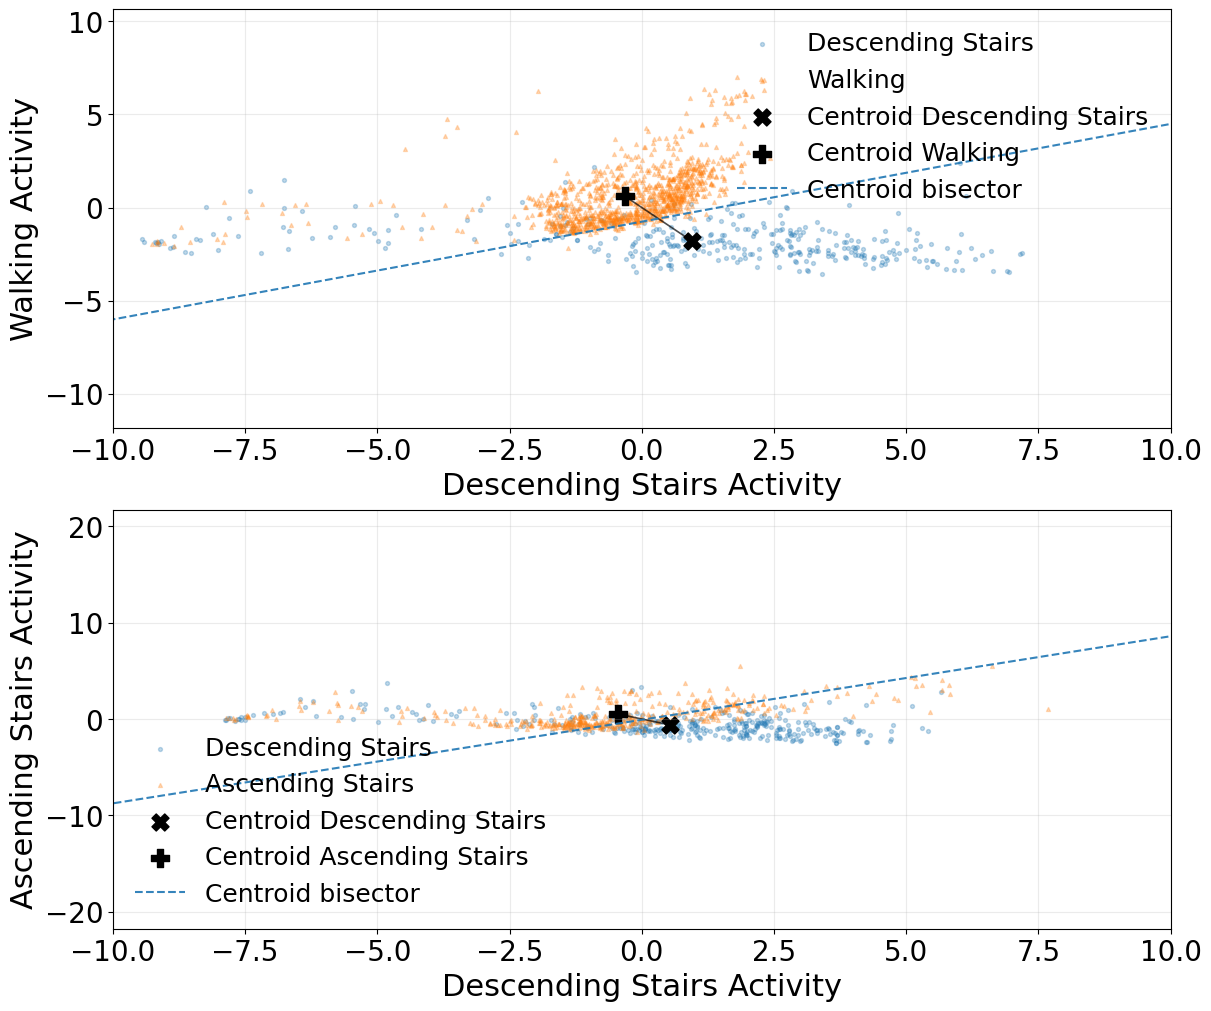

In [ ]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-

import re
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# Styling
rcParams["font.size"] = 22
rcParams["axes.labelsize"] = 22
rcParams["xtick.labelsize"] = 20
rcParams["ytick.labelsize"] = 20
rcParams["legend.fontsize"] = 18

# ===== CONFIG =====
DATA_ROOT = "datasets/PAMAP2_Dataset"
WIN_SECONDS = 5.0
STEP_SECONDS = 2.5
FS = 100
DROP_MAGNETOMETERS = True
USE_VECTOR_NORMS = True
FEATURE_STATS = ("std", "rms")
SEED = 42

BOUNDARY_MODE = "bisector"   # "bisector" or "lda"

ALPHA = 0.28
POINT_SIZE = 8
FIG_SIZE = (12.0, 10.0)

# Axes limits (your request)
X_LIMITS = (-10, 10)     # apply to both panels
Y_LIMITS = None          # set like (-2, 4) if you want fixed y as well

# Scenarios (majority_id, minority_id, label strings for legend only)
SCENARIO_1 = (13, 4)     # Descending vs Walking
SCENARIO_2 = (13, 12)    # Descending vs Ascending

PNG_NAME = "pamap2_pca2_separability_two_panel.png"
# ==================

ACTIVITY_NAMES = {
    1: "Lying", 2: "Sitting", 3: "Standing", 4: "Walking",
    5: "Running", 6: "Cycling", 7: "Nordic Walking",
    12: "Ascending Stairs", 13: "Descending Stairs", 16: "Vacuum Cleaning",
    17: "Ironing", 24: "Rope Jumping"
}

def _colnames():
    cols = ["timestamp", "activity_id", "heart_rate"]
    sub = [
        "temp","acc16g_x","acc16g_y","acc16g_z","acc6g_x","acc6g_y","acc6g_z",
        "gyro_x","gyro_y","gyro_z","mag_x","mag_y","mag_z",
        "orient_w","orient_x","orient_y","orient_z"
    ]
    for p in ["hand", "chest", "ankle"]:
        cols += [f"{p}_{s}" for s in sub]
    return cols

def _parse_subject_id(path: Path) -> str:
    m = re.search(r"subject(\d+)", path.stem.lower())
    return m.group(1) if m else "unknown"

def _load_all_dat_files(data_root: str) -> pd.DataFrame:
    root = Path(data_root)
    files = []
    for sub in ["Protocol", "Optional", "protocol", "optional"]:
        d = root / sub
        if d.exists():
            files += list(d.glob("subject*.dat"))
    if not files:
        raise FileNotFoundError(f"No .dat files found under {root}.")
    files = sorted(files, key=lambda p: (p.parent.name.lower(), p.name.lower()))
    rows = []
    for f in files:
        df = pd.read_csv(f, sep=r"\s+", header=None, names=_colnames(),
                         engine="python", na_values=["NaN","nan"])
        df["subject_id"] = _parse_subject_id(f)
        rows.append(df)
    return pd.concat(rows, ignore_index=True)

def _interpolate_per_subject(df: pd.DataFrame) -> pd.DataFrame:
    num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    num_cols = [c for c in num_cols if c != "activity_id"]
    df = df.sort_values(["subject_id", "timestamp"])
    df = df.groupby("subject_id", group_keys=False).apply(
        lambda g: g.assign(**{c: g[c].interpolate(limit_direction="both") for c in num_cols})
    )
    return df.reset_index(drop=True)

def _build_base_channels(df: pd.DataFrame, drop_magnetometers=True, use_vector_norms=True):
    imu_pos = ["hand", "chest", "ankle"]
    ACC16 = ["acc16g_x","acc16g_y","acc16g_z"]
    GYR   = ["gyro_x","gyro_y","gyro_z"]
    MAG   = ["mag_x","mag_y","mag_z"]
    keep_triplets = [("acc", ACC16), ("gyr", GYR)]
    if not drop_magnetometers: keep_triplets.append(("mag", MAG))
    base_cols = ["heart_rate"]
    if use_vector_norms:
        for p in imu_pos:
            for name, axes in keep_triplets:
                cols = [f"{p}_{a}" for a in axes]
                df[f"{p}_{name}_norm"] = np.sqrt((df[cols].values ** 2).sum(axis=1))
                base_cols.append(f"{p}_{name}_norm")
    else:
        for p in imu_pos:
            for _, axes in keep_triplets:
                for a in axes:
                    base_cols.append(f"{p}_{a}")
    return df, base_cols

def _window_features(df: pd.DataFrame, base_cols, fs=100, win_s=5.0, step_s=2.5, stats=("std","rms")):
    WIN = int(win_s * fs)
    STEP = int(step_s * fs)
    df = df.sort_values(["subject_id","timestamp"]).reset_index(drop=True)
    feats_rows, labels, subjects = [], [], []
    compute_std  = ("std"  in stats)
    compute_rms  = ("rms"  in stats)
    compute_mean = ("mean" in stats)
    for sid, g in df.groupby("subject_id", sort=False):
        g = g.reset_index(drop=True); n = len(g)
        if n < WIN: continue
        for start in range(0, n - WIN + 1, STEP):
            w = g.iloc[start:start + WIN]
            Xw = w[base_cols]
            y_win = int(np.bincount(w["activity_id"].astype(int)).argmax())
            fdict = {}
            if compute_mean: fdict.update(Xw.mean().add_suffix("__mean").to_dict())
            if compute_std:  fdict.update(Xw.std(ddof=1).add_suffix("__std").to_dict())
            if compute_rms:  fdict.update((np.sqrt((Xw**2).mean())).add_suffix("__rms").to_dict())
            fdict["subject_id"] = sid
            feats_rows.append(fdict); labels.append(y_win); subjects.append(sid)
    feat_df = pd.DataFrame(feats_rows).fillna(0.0)
    return feat_df, np.asarray(labels, dtype=int), np.asarray(subjects)

def _plot_linear_boundary(ax, mode, X2, y_bin, m0, m1):
    x_min, x_max = ax.get_xlim()
    xs = np.linspace(x_min, x_max, 200)
    if mode == "lda":
        lda = LinearDiscriminantAnalysis().fit(X2, y_bin)
        w = lda.coef_[0]; b = lda.intercept_[0]
        if np.isclose(w[1], 0.0):
            x0 = -b / (w[0] if w[0] != 0 else 1e-9)
            ax.axvline(x0, linestyle="--", linewidth=1.5, alpha=0.9, label="LDA boundary"); return
        ys = -(b + w[0]*xs) / w[1]
        ax.plot(xs, ys, linestyle="--", linewidth=1.5, alpha=0.9, label="LDA boundary")
    else:
        n = (m1 - m0)
        if np.allclose(n, 0): return
        mid = 0.5*(m0 + m1)
        v = np.array([-n[1], n[0]]) / (np.linalg.norm(n) + 1e-12)
        span = (x_max - x_min) * 1.2
        p1 = mid - span * v; p2 = mid + span * v
        ax.plot([p1[0], p2[0]], [p1[1], p2[1]], linestyle="--", linewidth=1.5, alpha=0.9, label="Centroid bisector")

def _render_scenario(ax, feat_df_all, y_all, majority_id, minority_id, name):
    mask = np.isin(y_all, [majority_id, minority_id])
    feat_df = feat_df_all.loc[mask].reset_index(drop=True)
    y_raw   = y_all[mask]
    y_bin = np.where(y_raw == minority_id, 1, 0)

    feat_cols = [c for c in feat_df.columns if c != "subject_id"]
    X = feat_df[feat_cols].values
    X2 = PCA(n_components=2, svd_solver="full", random_state=SEED)\
         .fit_transform(StandardScaler().fit_transform(X))

    m0 = X2[y_bin == 0].mean(axis=0)
    m1 = X2[y_bin == 1].mean(axis=0)

    maj_name = ACTIVITY_NAMES.get(majority_id, f"ID {majority_id}")
    min_name = ACTIVITY_NAMES.get(minority_id, f"ID {minority_id}")

    ax.scatter(X2[y_bin==0, 0], X2[y_bin==0, 1], s=POINT_SIZE, alpha=ALPHA, marker="o", label=maj_name)
    ax.scatter(X2[y_bin==1, 0], X2[y_bin==1, 1], s=POINT_SIZE, alpha=ALPHA, marker="^", label=min_name)

    ax.scatter([m0[0]], [m0[1]], s=150, c="black", marker="X", label=f"Centroid {maj_name}")
    ax.scatter([m1[0]], [m1[1]], s=150, c="black", marker="P", label=f"Centroid {min_name}")
    ax.plot([m0[0], m1[0]], [m0[1], m1[1]], c="black", lw=1.2, alpha=0.7)

    _plot_linear_boundary(ax, BOUNDARY_MODE, X2, y_bin, m0, m1)

    # Labels only (no titles)
    ax.set_xlabel("Descending Stairs Activity")
    ax.set_ylabel(name)   # 'Walking' in Scenario 1, 'Ascending Stairs' in Scenario 2
    ax.grid(alpha=0.25)
    ax.legend(loc="best", frameon=False)

    # Apply limits
    if X_LIMITS is not None: ax.set_xlim(*X_LIMITS)
    if Y_LIMITS is not None: ax.set_ylim(*Y_LIMITS)

def main():
    print("[info] loading + preprocessing…")
    raw = _load_all_dat_files(DATA_ROOT)
    raw = _interpolate_per_subject(raw)
    raw, base_cols = _build_base_channels(raw, DROP_MAGNETOMETERS, USE_VECTOR_NORMS)
    feat_df_all, y_all, _ = _window_features(raw, base_cols, FS, WIN_SECONDS, STEP_SECONDS, FEATURE_STATS)
    if feat_df_all.empty: raise RuntimeError("No windows produced — check DATA_ROOT.")

    fig, axes = plt.subplots(2, 1, figsize=FIG_SIZE, constrained_layout=True)
    _render_scenario(axes[0], feat_df_all, y_all, *SCENARIO_1, "Walking Activity")  # top
    _render_scenario(axes[1], feat_df_all, y_all, *SCENARIO_2, "Ascending Stairs Activity")  # bottom

    plt.savefig(PNG_NAME, dpi=220)
    print(f"[info] saved → {PNG_NAME}")
    plt.show()

if __name__ == "__main__":
    main()
